In [21]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
import numpy as np

import math
import cmath
np.set_printoptions(precision = 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Token var=<ContextVar name='format_options' default={'edgeitems': 3, 'threshold': 1000, 'floatmode': 'maxprec', 'precision': 8, 'suppress': False, 'linewidth': 75, 'nanstr': 'nan', 'infstr': 'inf', 'sign': '-', 'formatter': None, 'legacy': 9223372036854775807, 'override_repr': None} at 0x11612bc90> at 0x125862ac0>

In [22]:
import matplotlib
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [23]:
"""Modules with tools for representing qudit Clifford matrices as symplectic matrices.
We are ignoring phases everywhere, and so everything is 'up to Paulis'.
The symplectic matrices are constructed according to the order (x1,z1,x2,z2,...) and hence not in terms of Z and X blocks.
"""
import os.path
# from sympy import symbols
from sympy import symbols, groebner, Matrix, eye, Symbol, mod_inverse

Hmat = Matrix([[0,-1],[1,0]])
H2mat = Matrix([[-1,0],[0,-1]])
Hinvmat = Matrix([[0,1],[-1,0]])
idmat = Matrix([[1,0],[0,1]])
SWAPmat = Matrix([
                [0,0,1,0],
                [0,0,0,1],
                [1,0,0,0],
                [0,1,0,0]])

def Smat(rep):
    """Create a matrix representing `rep` repetitions of the S gate."""
    return Matrix([[1  ,0],
                   [rep,1]])

def MULmat(mul, dim):
    return Matrix([[mul,0],
                   [0,mod_inverse(mul,dim)]])

def CXmat(rep):
    return Matrix([
                [1  ,0,0,0],
                [0  ,1,0,-rep],
                [rep,0,1,0],
                [0  ,0,0,1]])

def CZmat(rep):# TODO: check minus sign
    return Matrix([
                [1  ,0,0  ,0],
                [0  ,1,rep,0],
                [0  ,0,1  ,0],
                [rep,0,0  ,1]])

def embed_block(block, n, mapping):
    """
    Embed a 2k x 2k symplectic 'block' into a 2n x 2n matrix.
    
    Parameters
    ----------
    block   : sympy.Matrix (2k x 2k)
              Symplectic block defined on local qudits [0..k-1],
              ordered [x0, z0, x1, z1, ...].
    n       : int
              Total number of qudits in the global system.
    mapping : list[int]
              Mapping of local qudits to global qudits.
              E.g. [2,4] means local 0 → global 2, local 1 → global 4.
    """
    k = len(mapping)
    assert block.shape == (2*k, 2*k)

    M = eye(2*n)

    # Local-to-global index map
    idx = []
    for q in mapping:
        idx.extend([2*q, 2*q+1])  # (x_q, z_q) in global basis order

    # Place the block into M
    for r in range(2*k):
        for c in range(2*k):
            M[idx[r], idx[c]] = block[r, c]

    return M

def ID(num_qudits):
    return eye(2*num_qudits)

def H(target, num_qudits, reps=1):
    if reps % 4 == 1: mat = Hmat
    elif reps % 4 == 2: mat = H2mat
    elif reps % 4 == 3: mat = Hinvmat
    else: mat = idmat
    return embed_block(mat, num_qudits, [target])

def MUL(target, num_qudits, mul, dim):
    mat = MULmat(mul, dim)
    return embed_block(mat, num_qudits, [target])

def S(target, num_qudits, reps=1):
    mat = Smat(reps)
    return embed_block(mat, num_qudits, [target])


def CX(control, target, num_qudits, reps=1):
    mat = CXmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def CZ(control, target, num_qudits, reps=1):
    mat = CZmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def SWAP(control, target, num_qudits):
    return embed_block(SWAPmat, num_qudits, [control,target])

def modulo_matrix(M, p):
    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = entry % p 
            newrow.append(entry)
        reduced_entries.append(newrow)
    # Test
    # print(p)
    return Matrix(reduced_entries)

def reduce_matrix(M, params: list[tuple[Symbol,Symbol]]):
    """Given a matrix containing parameters, reduces it by applying simple identities.
    params should be a list of tuples (param, invparam) where we interpret invparam = param^{-1}"""
    
    flattened = [a for (a,ainv) in params] + [ainv for (a,ainv) in params]
    G = groebner([a*ainv - 1 for (a,ainv) in params], *flattened)

    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = G.reduce(entry)[1]  
            newrow.append(entry)
        reduced_entries.append(newrow)
    return Matrix(reduced_entries)

def compare_matrices(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        m1 = modulo_matrix(m1,modulus)
        m2 = modulo_matrix(m2,modulus)
    return m1 == m2

def compare_matrices2(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        a = symbols("a")
        ainv = symbols("ainv")
        b = symbols("b")
        binv = symbols("binv")
        m1_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m2_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m1_reduce = modulo_matrix(m1_reduce,modulus)
        m2_reduce = modulo_matrix(m2_reduce,modulus)
    return m1_reduce == m2_reduce

In [24]:
S = dizx.gates.S(0)
H = dizx.gates.HAD(0)

# Verify the symplectic version of single-qupit relations in Figure 1

In what follows, We use AB to denote two gates A and B composed in diagrammatic order.

- $C_2$: $H^4 \;\underset{}{\widehat{=}}\; I$.
- $C_3$: $S^p \;\underset{}{\widehat{=}}\; I$.
- $C_4$: $SHSHSH \;\underset{}{\widehat{=}}\; I$.
- $C_5$: $H^2SH^2S^{p-1} \;\underset{}{\widehat{=}}\; I$.

p= 23


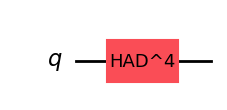

Matrix([[1, 0], [0, 1]])


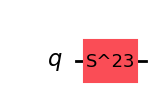

Matrix([[1, 0], [23, 1]])


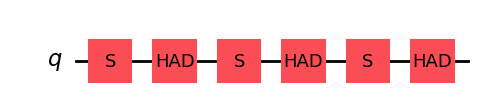

Matrix([[1, 0], [0, 1]])


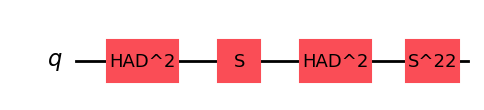

Matrix([[1, 0], [23, 1]])
OPENQASM 2.0;
include "qelib1.inc";
quditdim 23
qreg q[1];
h^4 q[0];



In [25]:
# from sympy import symbols
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    C2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C2lhs += H ** 4
    if dizx.symplectic.compare_matrices(C2lhs.to_symplectic_matrix(), C2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C2 fails")

    C3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C3lhs += S ** p
    if dizx.symplectic.compare_matrices(C3lhs.to_symplectic_matrix(), C3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C3 fails")

    C4lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C4lhs += S + H + S + H + S + H
    if dizx.symplectic.compare_matrices(C4lhs.to_symplectic_matrix(), C4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C4 fails")

    C5lhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5rhs = dizx.Circuit(qudit_amount=1, dim=p)
    C5lhs += H ** 2 + S + H ** 2 + S ** (p-1)
    if dizx.symplectic.compare_matrices(C5lhs.to_symplectic_matrix(), C5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Test C5 fails")

# Output the symplectic matrices
print("p=", p)
display(C2lhs.draw())
print(C2lhs.to_symplectic_matrix())
display(C3lhs.draw())
print(C3lhs.to_symplectic_matrix())
display(C4lhs.draw()) 
print(C4lhs.to_symplectic_matrix())   
display(C5lhs.draw()) 
print(C5lhs.to_symplectic_matrix())
print(C2lhs.to_qasm())


# Output the qasm file
save_to_path = '/Users/sarahli/Desktop/PhD-Projects/2025/QupitClifford-Verification/circuits'
name_of_file = 'C2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC2:
    fC2.write(C2lhs.to_qasm())

name_of_file = 'C3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC3:
    fC3.write(C3lhs.to_qasm())

name_of_file = 'C4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC4:
    fC4.write(C4lhs.to_qasm())

name_of_file = 'C5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fC5:
    fC5.write(C5lhs.to_qasm())

# Verify the action of A boxes on the Pauli generators
- $A_{0b}$, $b \in \mathbb{Z}_p^*$
- $A_{ab}$, $a \in \mathbb{Z}_p^*$, $b \in \mathbb{Z}_p$

In [34]:
# Define A and E boxes that appear in the single-qupit box relations
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")

A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H

Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

Ab0 = dizx.Circuit(qudit_amount=1, dim=p)
Ab0 += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b) + H

Aa0 = dizx.Circuit(qudit_amount=1, dim=p)
Aa0 += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a) + H

A0_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
A0_neg_a += H**-1 + S**-ainv + H**-1 + S**-a + H

Ab_neg_a = dizx.Circuit(qudit_amount=1, dim=p)
Ab_neg_a += H**-1 + S**-b + H**-1 + S**-binv + H**-1 + S**(-b*(-a+1)) + H

Aa_bminusa = dizx.Circuit(qudit_amount=1, dim=p)
Aa_bminusa += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b-a+1)) + H

Eb = dizx.Circuit(qudit_amount=1, dim=p)
Eb += S**(-b)

E_bminus1 = dizx.Circuit(qudit_amount=1, dim=p)
E_bminus1 += S**-(b-1)

In [36]:
A0b_m = A0b.to_symplectic_matrix()
A0b_m_reduce = dizx.symplectic.reduce_matrix(A0b_m,[(a,ainv),(b,binv)])
Aab_m = Aab.to_symplectic_matrix()
Aab_m_reduce = dizx.symplectic.reduce_matrix(Aab_m,[(a,ainv),(b,binv)])

print(A0b_m_reduce)
print(Aab_m_reduce)

name_of_file = 'A0b'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fA0b:
    fA0b.write(A0b.to_qasm())

name_of_file = 'Aab'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fAab:
    fAab.write(Aab.to_qasm())
# print(p)

Matrix([[b, 0], [-1, binv]])
Matrix([[b, -a], [ainv, 0]])


# Verify the action of E boxes on the Pauli generators
- $E_{b}$, $b \in \mathbb{Z}_p$

In [37]:
Eb_m = Eb.to_symplectic_matrix()
Eb_m_reduce = dizx.symplectic.reduce_matrix(Eb_m,[(b,binv)])

print(Eb_m_reduce)

name_of_file = 'Eb'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fEb:
    fEb.write(Eb.to_qasm())

Matrix([[1, 0], [-b, 1]])


# Single-qupit box relations

In [40]:
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += H + A0b
BR1rhs += Ab0 + S**(-binv)

BR2lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR2lhs += H + Aa0
BR2rhs += A0_neg_a + S**(-ainv)

BR3lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR3lhs += H + Aab
BR3rhs += Ab_neg_a + S**(ainv * binv)

BR4lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR4lhs += S + A0b
BR4rhs += A0b + (S**binv)**binv

BR5lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR5lhs += S + Aab
BR5rhs += Aa_bminusa

BR6lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR6lhs += S + Eb
BR6rhs += E_bminus1

## Print each single-qupit box relation to two qasm files

In [41]:
name_of_file = 'BR1-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_lhs:
    fBR1_lhs.write(BR1lhs.to_qasm())
name_of_file = 'BR1-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR1_rhs:
    fBR1_rhs.write(BR1rhs.to_qasm())

name_of_file = 'BR2-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_lhs:
    fBR2_lhs.write(BR2lhs.to_qasm())
name_of_file = 'BR2-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR2_rhs:
    fBR2_rhs.write(BR2rhs.to_qasm())

name_of_file = 'BR3-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_lhs:
    fBR3_lhs.write(BR3lhs.to_qasm())
name_of_file = 'BR3-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR3_rhs:
    fBR3_rhs.write(BR3rhs.to_qasm())

name_of_file = 'BR4-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_lhs:
    fBR4_lhs.write(BR4lhs.to_qasm())
name_of_file = 'BR4-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR4_rhs:
    fBR4_rhs.write(BR4rhs.to_qasm())

name_of_file = 'BR5-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_lhs:
    fBR5_lhs.write(BR5lhs.to_qasm())
name_of_file = 'BR5-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR5_rhs:
    fBR5_rhs.write(BR5rhs.to_qasm())

name_of_file = 'BR6-lhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_lhs:
    fBR6_lhs.write(BR6lhs.to_qasm())
name_of_file = 'BR6-rhs'
complete_name = os.path.join(save_to_path, name_of_file+".qasm")
with open(complete_name, 'w+') as fBR6_rhs:
    fBR6_rhs.write(BR6rhs.to_qasm())

## Print all single-qupit box relations

BR1-LHS:


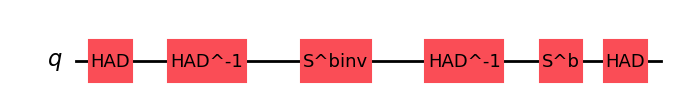

BR1-RHS:


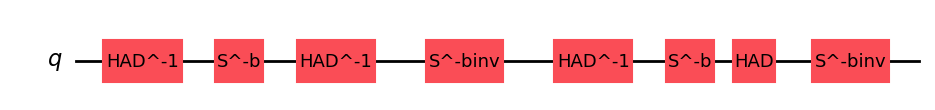

BR2-LHS:


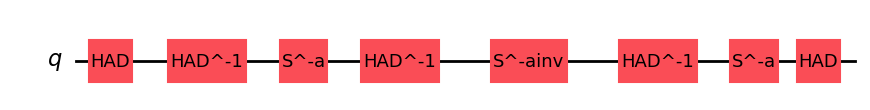

BR2-RHS:


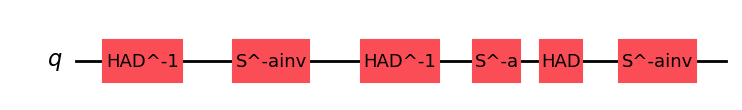

BR3-LHS:


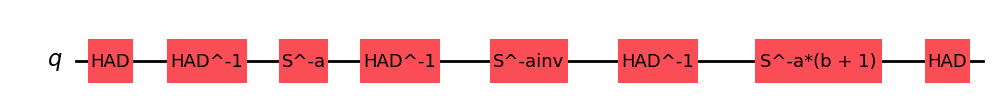

BR3-RHS:


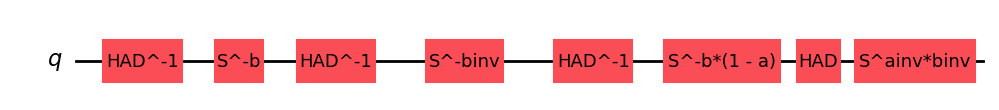

BR4-LHS:


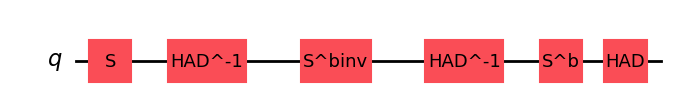

BR4-RHS:


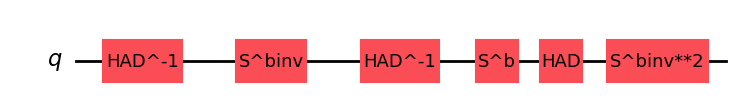

BR5-LHS:


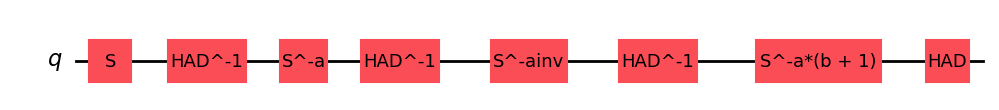

BR5-RHS:


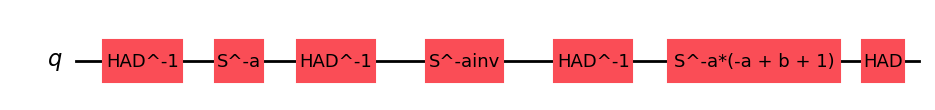

BR6-LHS:


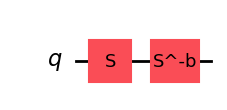

BR6-RHS:


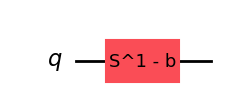

In [44]:
print("BR1-LHS:")
display(BR1lhs.draw())
print("BR1-RHS:")
display(BR1rhs.draw())

print("BR2-LHS:")
display(BR2lhs.draw())
print("BR2-RHS:")
display(BR2rhs.draw())

print("BR3-LHS:")
display(BR3lhs.draw())
print("BR3-RHS:")
display(BR3rhs.draw())

print("BR4-LHS:")
display(BR4lhs.draw())
print("BR4-RHS:")
display(BR4rhs.draw())

print("BR5-LHS:")
display(BR5lhs.draw())
print("BR5-RHS:")
display(BR5rhs.draw())

print("BR6-LHS:")
display(BR6lhs.draw())
print("BR6-RHS:")
display(BR6rhs.draw())

## The symplectic check of six single-qupit box relations

In [ ]:
primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    if dizx.symplectic.compare_matrices2(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 1 fails.")
    if dizx.symplectic.compare_matrices2(BR2lhs.to_symplectic_matrix(), BR2rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 2 fails.")
    if dizx.symplectic.compare_matrices2(BR3lhs.to_symplectic_matrix(), BR3rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 3 fails.")
    if dizx.symplectic.compare_matrices2(BR4lhs.to_symplectic_matrix(), BR4rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 4 fails.")
    if dizx.symplectic.compare_matrices2(BR5lhs.to_symplectic_matrix(), BR5rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 5 fails.")
    if dizx.symplectic.compare_matrices2(BR6lhs.to_symplectic_matrix(), BR6rhs.to_symplectic_matrix(), modulus=p) == False:
        print("Box Relation 6 fails.")

3
5
7
11
13
19
23
23


In [ ]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Aab = dizx.Circuit(qudit_amount=1, dim=p)
Aab += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H
A0b = dizx.Circuit(qudit_amount=1, dim=p)
A0b += H**-1 + S**binv + H**-1 + S**b + H
m = A0b.to_symplectic_matrix()
print(m)
print(dizx.symplectic.reduce_matrix(m,[(a,ainv),(b,binv)]))
BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
BR1lhs += S + A0b
BR1rhs += A0b + (S**binv)**binv
mlhs = BR1lhs.to_symplectic_matrix()
print("S.A0b")
print(mlhs)
print(dizx.symplectic.reduce_matrix(mlhs,[(a,ainv),(b,binv)]))
BR1rhs += A0b + (S**binv)**binv
mrhs = BR1rhs.to_symplectic_matrix()
print("A0b.dir")
print(mrhs)
print(dizx.symplectic.reduce_matrix(mrhs,[(a,ainv),(b,binv)]))
# primes = [3, 5, 7, 11, 13, 19, 23]
# for p in primes:
#     BR1lhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1rhs = dizx.Circuit(qudit_amount=1, dim=p)
#     BR1lhs += S + A0b
#     BR1rhs += A0b + (S**binv)**binv
#     print(dizx.symplectic.compare_matrices(BR1lhs.to_symplectic_matrix(), BR1rhs.to_symplectic_matrix(), modulus=p))

Matrix([[b, -b*binv + 1], [-1, binv]])
Matrix([[b, 0], [-1, binv]])
S.A0b
Matrix([[-b*(binv - 1) + 1, -b*binv + 1], [binv - 1, binv]])
Matrix([[b, 0], [binv - 1, binv]])
A0b.dir
Matrix([[b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1, -b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv], [-b + binv**2*(b*binv**2 - b*(-b + binv*(b*binv**2 - 1)) - 1) + binv*(b*binv**2 - 1), b*binv + binv**2*(-b*(b*binv + binv*(binv**2*(-b*binv + 1) + binv) - 1) + binv**2*(-b*binv + 1) + binv) + binv*(binv**2*(-b*binv + 1) + binv) - 1]])
Matrix([[b**2, 0], [-b + binv**2 - binv + 1, binv**2]])


In [5]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

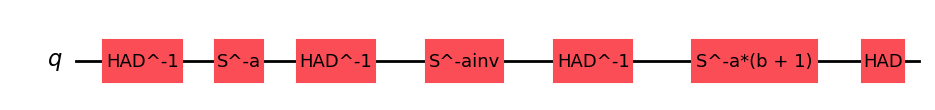

In [6]:
lhs.draw()

Matrix([[1, 0], [a, 1]])


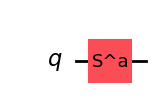

In [12]:
# C1
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
# S0 = S(0,1)
lhs += S ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [3]:
c = dizx.Circuit(qudit_amount=2,dim=3)
c.add_gates("H H S",0)
# c.add_gate("CZ",0,1)
# c.add_gates("S S H",1)
# c.add_gates("H S", 0)

In [4]:
print(c)

Circuit[3](2 qudits, 0 dits, [HAD(0), HAD(0), S(0)] gates)


In [12]:
# Experimenting with sympy's finite fields over polynomials
# Attempt 1 using Polynomial rings

from sympy import symbols, groebner, Matrix
from sympy.polys.domains import GF, PolynomialRing
from sympy.polys.matrices import DomainMatrix

p = 7
F = GF(p)
beta = symbols("beta")
b = symbols("b")
a = symbols("a")
ainv = symbols("a^{-1}")

# Polynomial ring GF(p)[a]
R = PolynomialRing(F, [a,ainv,b])

# testing
# R = PolynomialRing(F, [a,ainv,b,beta])

Ra = R.convert(a)
Rainv = R.convert(ainv)
# Rbeta = R.convert(beta)
Rb = R.convert(b)

G = groebner([a*ainv - 1], a, ainv, modulus=p)

H = DomainMatrix([[R.convert(0), R.convert(-1)],
                  [R.convert(1), R.convert(0)]],
                 (2, 2), R)

Hinv = DomainMatrix([[R.convert(0), R.convert(1)],
                  [R.convert(-1), R.convert(0)]],
                 (2, 2), R)


def S_repetitions(rep):
    return DomainMatrix([[R.convert(1), R.convert(0)],
                  [rep, R.convert(1)]],
                 (2, 2), R)

# Sbeta = S_repetitions(Rbeta)
Sb = S_repetitions(Rb)
# Build a matrix with entries in GF(p)[a]
A = DomainMatrix([[R.convert(1), R.convert(0)],
                  [R.convert(b), R.convert(1)]],
                 (2, 2), R)

print("Matrix over GF(p)[a]:")
print(A.to_Matrix())

aval = F(3)  # element of GF(7)

# Substitute 'a=3' in each entry
# evaluated_entries = [[entry.evaluate(0,aval) for entry in row]
#                      for row in A.to_list()]

# # Build a new matrix over GF(p)
# A_eval = DomainMatrix(evaluated_entries, A.shape, F)

# print("Matrix evaluated at a=3 (in GF(7)):")
# print(A_eval.to_Matrix())

Matrix over GF(p)[a]:
Matrix([[1, 0], [b, 1]])


In [11]:
# Attempt 2 using groebner bases to automate the reductions of the variables and say a*ainv = 1.
G = groebner([a*ainv - 1], a, ainv, b, modulus=p)
expr = a**2*ainv + 3
G.reduce(expr)

H = Matrix([[0,-1],[1,0]])
Hinv = Matrix([[0,1],[-1,0]])
H2 = Matrix([[-1,0],[0,-1]])


def Sr(rep):
    return Matrix([[1,0],[rep,1]])

M = H*Sr(-a*(b+1))*Hinv*Sr(-ainv)*Hinv*Sr(-a)*Hinv

def reduce_matrix(M):
    evaluated_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = G.reduce(entry)[1]
            newrow.append(entry)
        evaluated_entries.append(newrow)
    return Matrix(evaluated_entries)

reduce_matrix(M)

Matrix([
[   b, -a],
[ainv,  0]])

# The Qupit Equality Checking

In [13]:
from sympy import Matrix, symbols, expand
from sympy.polys import groebner

# symbols and field
a, ainv, b = symbols('a ainv b')
# p = 101  # your modulus

# ideal: a*ainv = 1 over GF(p)
G = groebner([a*ainv - 1], a, ainv, b, order='lex', modulus=p)

def nf(expr):
    # reduced (normal-form) representative modulo <a*ainv-1> over GF(p)
    return G.reduce(expand(expr))[1]

def normalize_matrix(M):
    # apply reduction entrywise
    return M.applyfunc(nf)

def matrices_equal(A, B):
    # equal iff their difference reduces to 0
    R = normalize_matrix(A - B)
    return R == Matrix.zeros(*A.shape)

# example usage:
# M = ... (your matrix)
# N = ... (another matrix built the same way)
# are_equal = matrices_equal(M, N)
# print(are_equal)


# The Qutrit Equality Checking

In [14]:
def equalUpToScalar(U, V, tol=1e-10):
    """
    Check if two unitary matrices U and V are equal up to (-w)^t, 
    where w is the third root of unity and t is in Z6.

    Parameters:
    U : np.ndarray
        The first symplectic matrix
    V : np.ndarray
        The second symplectic matrix
    tol : float
        The numerical tolerance for equality checks (default: 1e-10).

    Returns:
    bool : True if U and V are equal up to a scalar, False otherwise.
    """
    # Compute the third root of unity w
    # w = np.exp(2j * np.pi / 3)

    # Define the all-zero matrix based on the dimension and data type of the input matrix
    # zero_matrix = np.zeros_like(U)
    zero_matrix = Matrix([[0,0],[0,0]])
    
    # When V = U
    if np.allclose(V - U, zero_matrix, rtol=0, atol=tol):
        print("Exactly equal")
        return True
    else:
        print("Not equal")
        return False
    

In [8]:
from sympy import Matrix

M = Matrix([[1,0],[a,1]])
M.inv()

Matrix([
[ 1, 0],
[-a, 1]])

# Confirm the Single-Qupit Symplectic Completeness

In [15]:
# Test 1
H2 = H * H
print(H2)

H3 = H * H * H
print(H3)

H4 = H * H * H * H
print(H4)

DomainMatrix([[6 mod 7, 0 mod 7], [0 mod 7, 6 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[0 mod 7, 1 mod 7], [6 mod 7, 0 mod 7]], (2, 2), GF(7)[a,a^{-1},b])
DomainMatrix([[1 mod 7, 0 mod 7], [0 mod 7, 1 mod 7]], (2, 2), GF(7)[a,a^{-1},b])


In [16]:
# Test 2
S = Sr(1)
print("S: ", S)

S2 = Sr(2)
reduce_S2 = reduce_matrix(S2)
print("S2: ", reduce_S2)

S3 = Sr(3)
reduce_S3 = reduce_matrix(S3)
print("S3: ", reduce_S3)

S4 = Sr(4)
reduce_S4 = reduce_matrix(S4)
print("S4: ", reduce_S4)

S5 = Sr(5)
reduce_S5 = reduce_matrix(S5)
print("S5: ", reduce_S5)

S6 = Sr(6)
reduce_S6 = reduce_matrix(S6)
print("S6: ", reduce_S6)

Sp = Sr(p)
reduce_Sp = reduce_matrix(Sp)
print("Sp: ", reduce_Sp)

Sp1 = Sr(p+1)
reduce_Sp1 = reduce_matrix(Sp1)
print("Sp+1: ", reduce_Sp1)

print(p)

S:  Matrix([[1, 0], [1, 1]])
S2:  Matrix([[1, 0], [2, 1]])
S3:  Matrix([[1, 0], [3, 1]])
S4:  Matrix([[1, 0], [-3, 1]])
S5:  Matrix([[1, 0], [-2, 1]])
S6:  Matrix([[1, 0], [-1, 1]])
Sp:  Matrix([[1, 0], [0, 1]])
Sp+1:  Matrix([[1, 0], [1, 1]])
7


In [17]:
# Test 3: Figure 1, single qupit
LHS = H * S * H * S * H * S
RHS = Matrix([[1,0],[0,1]])
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))


LHS = H2 * S
RHS = S * H2
print(LHS)
print(RHS)
print(matrices_equal(LHS, RHS))

TypeError: cannot unpack non-iterable int object

In [13]:
# Test 4
input = Matrix([[a],[0]])
print(H * input)

input = Matrix([[0],[a]])
print(H * input)

input = Matrix([[0],[-a]])
print(H * input)

Matrix([[0], [a]])
Matrix([[-a], [0]])
Matrix([[a], [0]])


In [14]:
# Test 5
input = Matrix([[a],[0]])
print(S * input)

input = Matrix([[0],[a]])
print(S * input)

input = Matrix([[a],[-a]])
print(S * input)

Matrix([[a], [a]])
Matrix([[0], [a]])
Matrix([[a], [0]])


In [15]:
# Test 6
Sa = Sr(a)

input = Matrix([[1],[0]])
print(Sa * input)

input = Matrix([[0],[1]])
print(Sa * input)

input = Matrix([[1],[-a]])
print(Sa * input)

Matrix([[1], [a]])
Matrix([[0], [1]])
Matrix([[1], [0]])


In [16]:
# Test 7
Sb = Sr(b)

input = Matrix([[a],[0]])
print(Sb * input)

input = Matrix([[0],[a]])
print(Sb * input)

input = Matrix([[a],[-a * b]])
print(Sb * input)

Matrix([[a], [a*b]])
Matrix([[0], [a]])
Matrix([[a], [0]])


# Test multi-qudit gates

In [ ]:
# SWAP
SWAPmat
SWAP(0,2,4)

Matrix([
[0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
# Hadamard
# H0 = H(0, 2, reps=1)
# print(H0)
H(1, 3, reps=1)
# H(1, 3, reps=2)
# H(1, 3, reps=3)
# H(1, 3, reps=5)
# H1 = H(1, 2, reps=1)

Matrix([
[1, 0, 0,  0, 0, 0],
[0, 1, 0,  0, 0, 0],
[0, 0, 0, -1, 0, 0],
[0, 0, 1,  0, 0, 0],
[0, 0, 0,  0, 1, 0],
[0, 0, 0,  0, 0, 1]])

Matrix([[1, 0], [a, 1]])


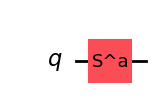

In [62]:
# def S(target, num_qudits, reps=1):
#     mat = Smat(reps)
#     return embed_block(mat, num_qudits, [target])
lhs = dizx.Circuit(qudit_amount=1, dim=5)
# S1 = S(1, 2, a)
# lhs += S1
S0 = S(0)
lhs += S0 ** a
print(lhs.to_symplectic_matrix())
display(lhs.draw())

In [19]:
H0 = H(0, 2, reps=1)
H1 = H(1, 2, reps=1)
S1 = S(0, 2, reps=2)
# C14l = CZ * H0 * CZ * H0 * CZ * S1
# C14r = H0 * CZ * H0
print(H0 == H1)

False


In [65]:
from dizx.circuit.gates import CZ, CX, HAD, S#, Z, X

lhs = dizx.Circuit(qudit_amount=2, dim=5)
lhs += CZ(0,1)
lhs += HAD(0)**2 + HAD(1)
lhs += CZ(0,1)
lhs += CX(1,0)
rhs = dizx.Circuit(qudit_amount=2, dim=5)
rhs += HAD(1)
rhs += CZ(0,1) + CX(1,0)
rhs += S(1)**2 + HAD(1)**2 + S(1)**2
rhs += CX(0,1)**2
rhs += S(1)**2 #+ Z(1)

In [66]:
dizx.symplectic.compare_matrices(lhs.to_symplectic_matrix(), rhs.to_symplectic_matrix(), modulus=3)

True

LHS of BR1


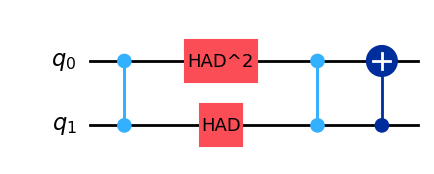

LHS of BR1


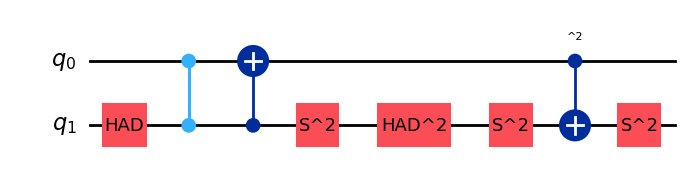

In [67]:
print("LHS of BR1")
display(lhs.draw())
print("LHS of BR1")
display(rhs.draw())

In [ ]:
r1-lhs = CZ * H0 * CZ * H0 * CZ * S1r(2)

primes = [3, 5, 7, 11, 13, 19, 23]
for p in primes:
    r1-lhs 

In [20]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp
Phase = dizx.CliffordPhase
d = 3
Z = dizx.VertexType.Z
X = dizx.VertexType.X

In [19]:
from sympy import symbols
a = symbols("a")
ainv = symbols("ainv")
b = symbols("b")
binv = symbols("binv")
Hadj = dizx.gates.HAD(0,adjoint=True)
H = dizx.gates.HAD(0)
S = dizx.gates.S(0)

lhs = dizx.Circuit(qudit_amount=1, dim=3)
lhs += H**-1 + S**-a + H**-1 + S**-ainv + H**-1 + S**(-a*(b+1)) + H

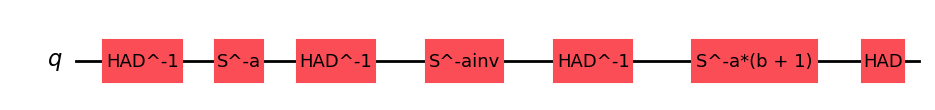

In [20]:
lhs.draw()